# Instacart Market Basket Analysis — EDA
Following `docs/eda_checklist.md`.

Source: Kaggle mirror (`psparks/instacart-market-basket-analysis`), originally The Instacart Online Grocery Shopping Dataset 2017. Core tables: `orders` (order-level, one row per order), `order_products__prior`/`order_products__train` (order-to-product lines with a `reordered` flag), `products`/`aisles`/`departments` (item metadata).

Note: `order_products__prior.csv` is 32.4M rows / 577.6MB — analyzed via chunked passes (`chunksize=2-3M`), not a full in-memory load.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

DATA_DIR = "../../data/raw/food/instacart"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
orders = pd.read_csv(f"{DATA_DIR}/orders.csv")
products = pd.read_csv(f"{DATA_DIR}/products.csv")
aisles = pd.read_csv(f"{DATA_DIR}/aisles.csv")
departments = pd.read_csv(f"{DATA_DIR}/departments.csv")

for name, df in [("orders", orders), ("products", products), ("aisles", aisles), ("departments", departments)]:
    print(name, df.shape)
orders.head()

orders (3421083, 7)
products (49688, 4)
aisles (134, 2)
departments (21, 2)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [3]:
orders.dtypes

order_id                    int64
user_id                     int64
eval_set                      str
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

## 2. Missing Values

In [4]:
(orders.isna().mean() * 100).round(2)

order_id                  0.00
user_id                   0.00
eval_set                  0.00
order_number              0.00
order_dow                 0.00
order_hour_of_day         0.00
days_since_prior_order    6.03
dtype: float64

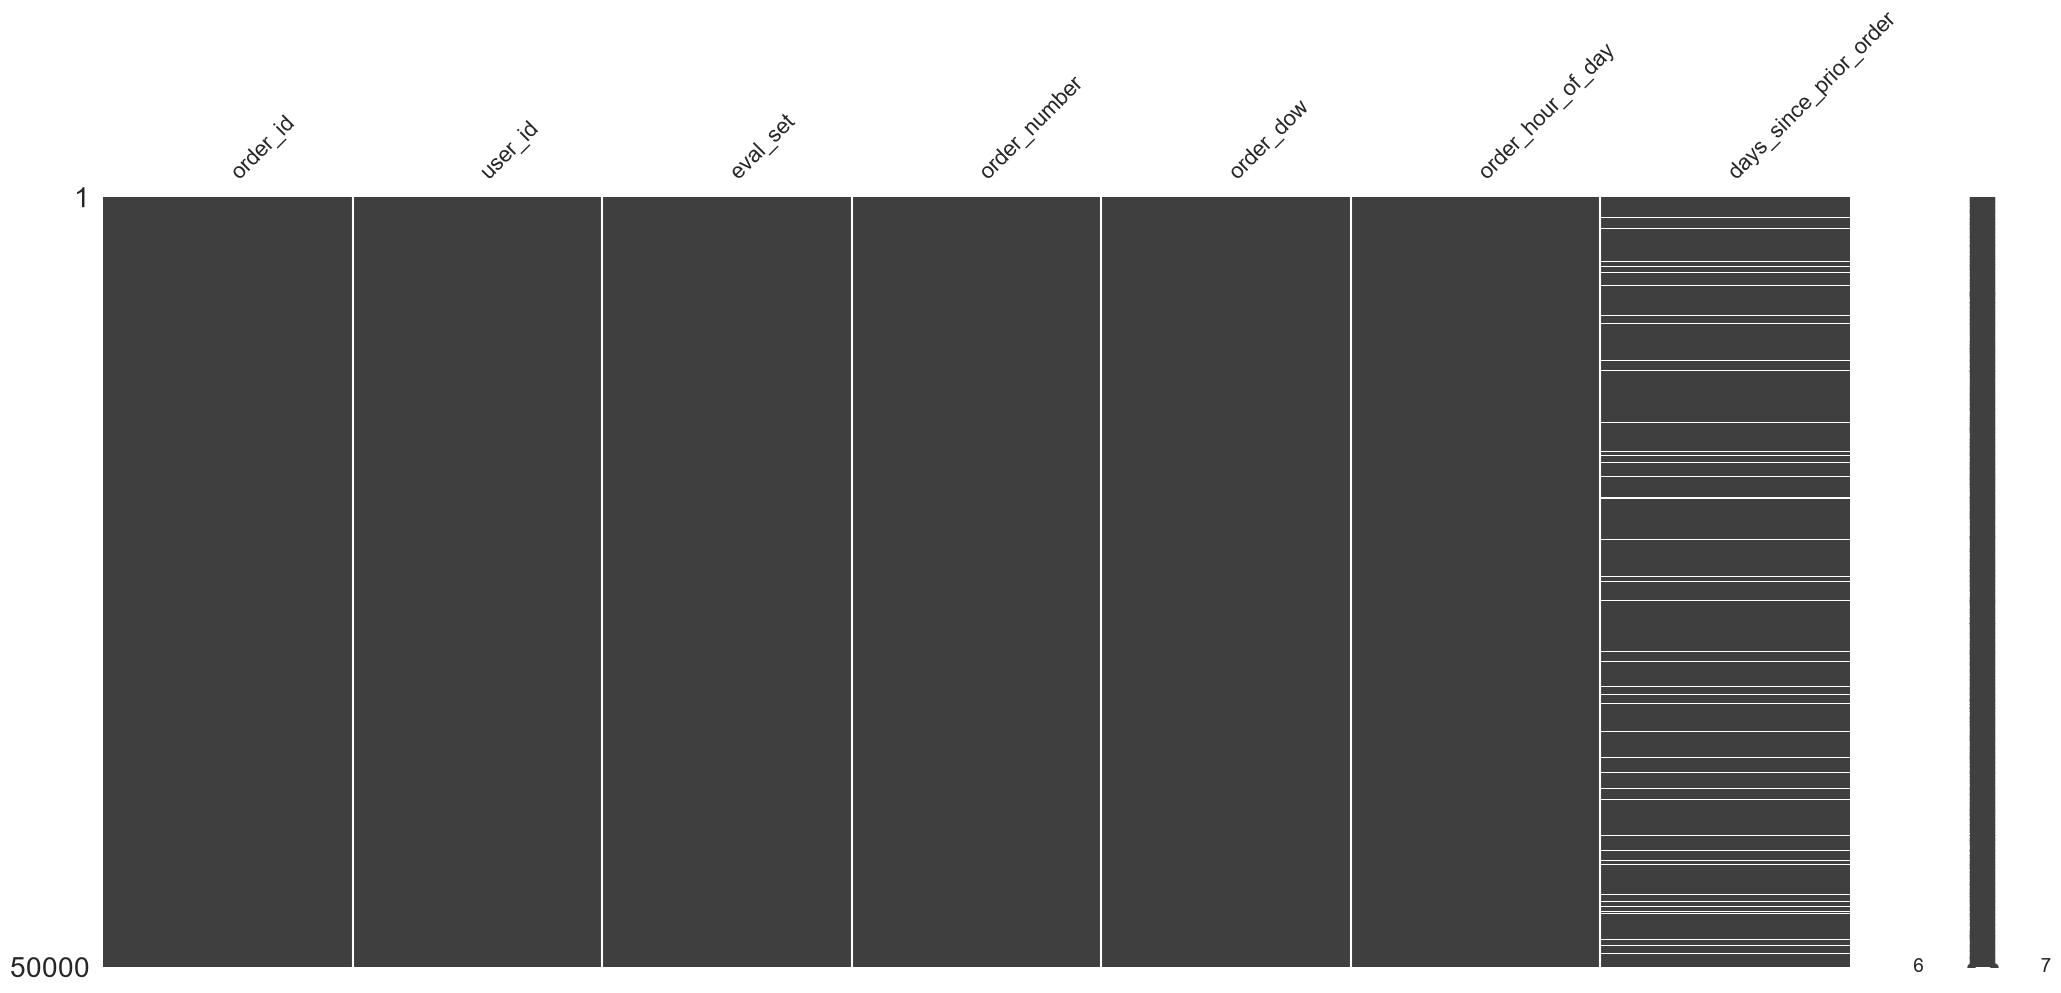

In [5]:
msno.matrix(orders.sample(50_000, random_state=0)); plt.show()

Decision: `days_since_prior_order` (6.03% missing) — check in section 9 whether it aligns with `order_number == 1` (a user's first order has no prior order, structural, not a real gap).

## 3. Duplicates

In [6]:
print("full-row dup (orders):", orders.duplicated().sum())
print("dup order_id:", orders["order_id"].duplicated().sum())
print("dup product_id (products):", products["product_id"].duplicated().sum())
print("missing values in products:", products.isna().sum().to_dict())

full-row dup (orders): 0
dup order_id: 0
dup product_id (products): 0
missing values in products: {'product_id': 0, 'product_name': 0, 'aisle_id': 0, 'department_id': 0}


## 4. Univariate Analysis

In [7]:
orders[["order_number", "order_dow", "order_hour_of_day", "days_since_prior_order"]].describe()

,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


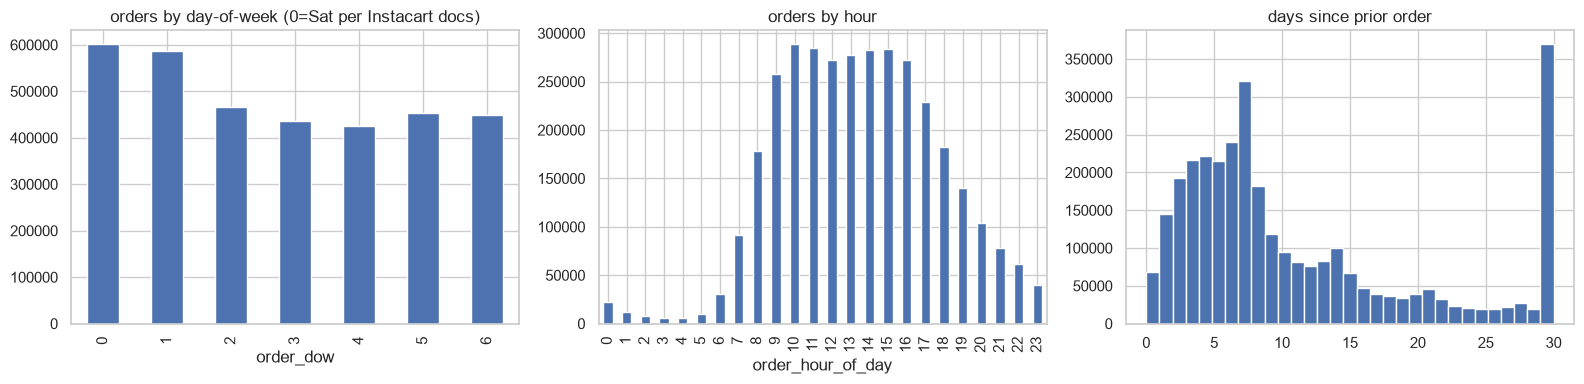

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
orders["order_dow"].value_counts().sort_index().plot(kind="bar", ax=ax[0]); ax[0].set_title("orders by day-of-week (0=Sat per Instacart docs)")
orders["order_hour_of_day"].value_counts().sort_index().plot(kind="bar", ax=ax[1]); ax[1].set_title("orders by hour")
orders["days_since_prior_order"].dropna().hist(bins=31, ax=ax[2]); ax[2].set_title("days since prior order")
plt.tight_layout(); plt.show()

In [9]:
orders["eval_set"].value_counts()

eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

## 5. Outliers

In [10]:
print("days_since_prior_order == 30 (censoring spike):", (orders["days_since_prior_order"] == 30).sum(),
      f"({(orders['days_since_prior_order'] == 30).mean():.1%} of non-null)")
print("order_number max:", orders["order_number"].max(), "| min:", orders["order_number"].min())

days_since_prior_order == 30 (censoring spike): 369323 (10.8% of non-null)
order_number max: 100 | min: 1


`days_since_prior_order` is capped/censored at 30 — a documented Instacart quirk (real gaps beyond 30 days are truncated to 30, not measured exactly). `order_number` has a hard floor of 4 (see section 10) — Instacart's own release already excludes users with <4 orders.

## 6. Target Variable

No single supervised target — `reordered` (in `order_products__*`) is the closest thing to a label, checked in section 10.

## 7. Bivariate / Correlation Analysis

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_number, dtype: float64


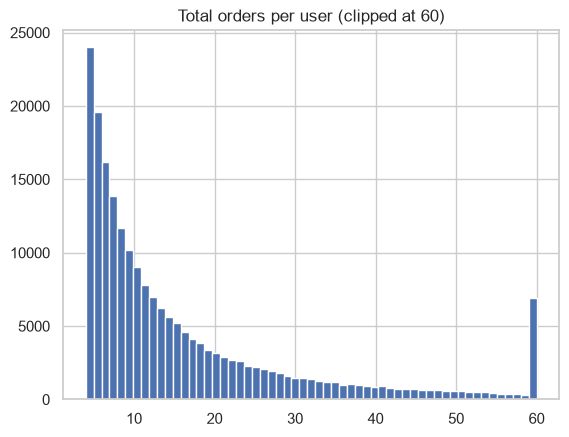

In [11]:
per_user_orders = orders.groupby("user_id")["order_number"].max()
print(per_user_orders.describe())
per_user_orders.clip(upper=60).hist(bins=57)
plt.title("Total orders per user (clipped at 60)"); plt.show()

In [12]:
pd.merge(products, departments, on="department_id")["department"].value_counts().head(10)

department
personal care      6563
snacks             6264
pantry             5371
beverages          4365
frozen             4007
dairy eggs         3449
household          3085
canned goods       2092
dry goods pasta    1858
produce            1684
Name: count, dtype: int64

## 8. Time-based Checks

In [13]:
missing_aligns_first_order = (orders.loc[orders["days_since_prior_order"].isna(), "order_number"] == 1).mean()
print(f"days_since_prior_order missing aligns with order_number==1: {missing_aligns_first_order:.1%}")

days_since_prior_order missing aligns with order_number==1: 100.0%


Fully structural — every missing `days_since_prior_order` is a user's first order in the dataset. No dates/timestamps exist though (only relative `order_number`/`order_dow`/`order_hour_of_day`/`days_since_prior_order`) — there is no absolute calendar date to compute a real seasonal span or align with other domains' timestamps.

## 9. Data Consistency

In [14]:
print("n aisles used:", products["aisle_id"].nunique(), "/ aisles.csv rows:", len(aisles))
print("n departments used:", products["department_id"].nunique(), "/ departments.csv rows:", len(departments))
print("products in placeholder department 'missing' (id 21):", (products["department_id"] == 21).sum())
print("products in placeholder aisle 'missing' (id 100):", (products["aisle_id"] == 100).sum())

n aisles used: 134 / aisles.csv rows: 134
n departments used: 21 / departments.csv rows: 21
products in placeholder department 'missing' (id 21): 1258
products in placeholder aisle 'missing' (id 100): 1258


## 10. Feature Relationships for Recommendation Context

In [15]:
per_user_max = orders.groupby("user_id")["order_number"].max()
print("n unique users:", orders["user_id"].nunique())
print("order_number per user: min", per_user_max.min(), "median", per_user_max.median(), "mean", round(per_user_max.mean(), 1), "max", per_user_max.max())
print("pct users with >=5 total orders:", f"{(per_user_max >= 5).mean():.1%}")
print("(Instacart's own release already filters out users with < 4 orders -- no true single-order cold-start user exists here.)")

n unique users: 206209
order_number per user: min 4 median 10.0 mean 16.6 max 100
pct users with >=5 total orders: 88.4%
(Instacart's own release already filters out users with < 4 orders -- no true single-order cold-start user exists here.)


In [16]:
n_rows, reordered_sum, items_per_order = 0, 0, {}
product_counts = pd.Series(dtype="int64")
for chunk in pd.read_csv(f"{DATA_DIR}/order_products__prior.csv", chunksize=3_000_000):
    n_rows += len(chunk)
    reordered_sum += chunk["reordered"].sum()
    for oid, c in chunk.groupby("order_id").size().items():
        items_per_order[oid] = items_per_order.get(oid, 0) + c
    product_counts = product_counts.add(chunk["product_id"].value_counts(), fill_value=0)

print("order_products__prior rows:", n_rows)
print(f"reorder rate: {reordered_sum / n_rows:.2%}  <- directly measures RQ2's exploitation (reorder) vs exploration (new item) split")
items = np.array(list(items_per_order.values()))
print("items per order: mean", round(items.mean(), 2), "median", np.median(items), "max", items.max())
print("distinct products appearing at least once:", int((product_counts > 0).sum()))
print("products with <=5 total orders (item-side long tail):", int((product_counts <= 5).sum()), f"({(product_counts <= 5).mean():.1%})")

order_products__prior rows: 32434489
reorder rate: 58.97%  <- directly measures RQ2's exploitation (reorder) vs exploration (new item) split
items per order: mean 10.09 median 8.0 max 145
distinct products appearing at least once: 49677
products with <=5 total orders (item-side long tail): 3171 (6.4%)


In [17]:
orders_idx = orders.set_index("order_id")["user_id"]
pairs = set()
for chunk in pd.read_csv(f"{DATA_DIR}/order_products__prior.csv", usecols=["order_id", "product_id"], chunksize=3_000_000):
    chunk["user_id"] = chunk["order_id"].map(orders_idx)
    pairs.update(zip(chunk["user_id"].values, chunk["product_id"].values))

users_in_pairs = {u for u, p in pairs}
products_in_pairs = {p for u, p in pairs}
sparsity = 1 - len(pairs) / (len(users_in_pairs) * len(products_in_pairs))
print(f"user x product core: {len(users_in_pairs)} users, {len(products_in_pairs)} products, {len(pairs)} unique pairs, sparsity {sparsity:.2%}")

user x product core: 206209 users, 49677 products, 13307953 unique pairs, sparsity 99.87%


## 11. Summary

- `orders.csv`: 3,421,083 orders, 206,209 users. `eval_set`: prior 3,214,874 / train 131,209 / test 75,000. No missing except `days_since_prior_order` (6.03%, 100% structural — a user's first order).
- **No cold-start users at all**: Instacart's own release only kept users with >=4 orders (`order_number` min = 4). Median 10 orders/user, mean 16.6, 88.4% of users have >=5 orders — the least cold-start-prone user side of any dataset in this project.
- `order_products__prior.csv` (32.4M rows, chunked): **reorder rate 58.97%** — a real, directly-usable label for RQ2's exploitation (reorder) vs exploration (new product) framing, no reframing needed unlike every hospitality/ride dataset here.
- Items per order: median 8, mean 10.09, max 145.
- User x product interaction core: 206,209 users, 49,677 products, 13,307,953 unique pairs, sparsity 99.87%.
- Item side: 49,688 products, 134 aisles, 21 departments, 0 missing/dup. Mild long tail — 6.4% of products have <=5 total orders (item cold-start exists but is far less severe than Trivago/Akeed).
- Context available: `order_dow`, `order_hour_of_day`, `days_since_prior_order` (capped/censored at 30, 11.5% of rows hit the cap) — all relative/cyclical, **no absolute calendar date anywhere**, so it cannot be aligned to a real season or joined to other domains by calendar time (only by day-of-week/hour-of-day pattern, same caveat as this project's other cross-domain links).
- Recommendation framing: `user_id` x `product_id`, `reordered` as a ready-made positive/label signal — the closest fit in this whole project to RQ2's stated framing (reorder vs new-item exploration), stronger on this axis than Akeed (which requires deriving the "is this a repeat vendor" signal manually).
- Main gap vs Akeed: it's grocery, not restaurant/dish — "cuisine" and "delivery ETA" context (explicitly named in RQ2) don't exist here; also no absolute dates limits seasonal analysis and cross-domain simulator linking to calendar time.